## Сетевой анализ ##

Строится однодольная проекция двудольного графа. Узлами будут стимулы. Ребра - общие ассоциации.

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import math
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities

In [ ]:
df2= pd.read_csv('1_base_list.csv')

In [ ]:
shared_lemmas = pd.read_csv('5_shared_lemmas.csv')

In [ ]:

stimulus_N = df2.groupby('стимул')['частота'].sum().to_dict()
freq_map = df2.set_index(['стимул', 'лемма'])['частота'].to_dict()

G2 = nx.Graph()

# пересечения из shared_lemmas
for _, row in shared_lemmas.iterrows():
    lemma = row['лемма']
    stims = [s.strip() for s in str(row['список стимулов']).split(',')]

    # без слишком общих лемм
    if len(stims) > 15:
        continue

    for i in range(len(stims)):
        for j in range(i + 1, len(stims)):
            s1, s2 = stims[i], stims[j]

            # частоты
            f_ap = freq_map.get((s1, lemma), 0)
            f_bp = freq_map.get((s2, lemma), 0)
            min_freq = min(f_ap, f_bp)

            if min_freq > 0:
                if G2.has_edge(s1, s2):
                    G2[s1][s2]['sum_min'] += min_freq
                else:
                    G2.add_edge(s1, s2, sum_min=min_freq)

# расчет коэффициента Диза
for u, v, d in list(G2.edges(data=True)):
    Nu = stimulus_N.get(u)
    Nv = stimulus_N.get(v)

    if Nu and Nv:
        denominator = math.sqrt((2 * Nu) * (2 * Nv))
        G2[u][v]['weight'] = d['sum_min'] / denominator
    else:
        G2[u][v]['weight'] = 0

G2.remove_edges_from([(u, v) for u, v, d in G2.edges(data=True) if d.get('weight', 0) == 0])

print(f"Узлов: {G2.number_of_nodes()}, Ребер: {G2.number_of_edges()}")



Узлов: 1000, Ребер: 98586


In [ ]:
#фильтрация
threshold_k = 0.016
G_final = G2.copy()
G_final.remove_edges_from([(u, v) for u, v, d in G_final.edges(data=True) if d.get('weight', 0) < threshold_k])
G_final.remove_nodes_from(list(nx.isolates(G_final)))

print(f"После фильтрации осталось: {G_final.number_of_nodes()} узлов и {G_final.number_of_edges()} ребер.")

После фильтрации осталось: 469 узлов и 434 ребер.


In [ ]:

edge_data = []
for u, v, d in G_final.edges(data=True):
    edge_data.append({
        'Стимул 1': u,
        'Стимул 2': v,
        'Коэффициент Диза': round(d['weight'], 4),
        'Сумма миним. частот': d['sum_min']
    })

df_top_edges = pd.DataFrame(edge_data).sort_values('Коэффициент Диза', ascending=False)

print("ТОП-20 самых сильных ассоциативных связей по Дизу:")
display(df_top_edges.head(20).style.hide(axis='index'))

ТОП-20 самых сильных ассоциативных связей по Дизу:


Стимул 1,Стимул 2,Коэффициент Диза,Сумма миним. частот
сесть,садиться,0.157600,157
упасть,падать,0.107400,107
северный,южный,0.083700,83
улыбнуться,улыбаться,0.078200,110
задний,передний,0.073800,72
вызывать,вызвать,0.071600,71
пройти,проходить,0.071300,71
сидеть,садиться,0.071100,71
возникнуть,возникать,0.070400,70
собираться,собраться,0.069300,69


In [ ]:
centrality_degree = nx.degree_centrality(G_final)
centrality_betweenness = nx.betweenness_centrality(G_final, weight='weight')
centrality_closeness = nx.closeness_centrality(G_final)

df_graph_metrics = pd.DataFrame({
    'стимул': list(G_final.nodes()),
    'количество связей': [d for n, d in G_final.degree()],
    'взвешенная степень': [d for n, d in G_final.degree(weight='weight')],
    'центральность по степени': [centrality_degree[node] for node in G_final.nodes()],
    'степень посредничества': [centrality_betweenness[node] for node in G_final.nodes()],
    'степень близости': [centrality_closeness[node] for node in G_final.nodes()]
}).sort_values('количество связей', ascending=False)

display(df_graph_metrics.head(20))

,стимул,количество связей,взвешенная степень,центральность по степени,степень посредничества,степень близости
38,давать,7,0.224759,0.014957,0.000247,0.017450
430,брать,6,0.201236,0.012821,0.000302,0.017450
60,поехать,6,0.181784,0.012821,0.000320,0.014410
375,попросить,6,0.175338,0.012821,0.000055,0.016108
372,дать,6,0.177645,0.012821,0.000256,0.016108
317,уезжать,6,0.171049,0.012821,0.002224,0.014553
139,появляться,6,0.159551,0.012821,0.001098,0.015436
188,предприятие,6,0.126490,0.012821,0.000110,0.013088
13,взять,6,0.221735,0.012821,0.000000,0.016108
241,относиться,5,0.105390,0.010684,0.000119,0.012363


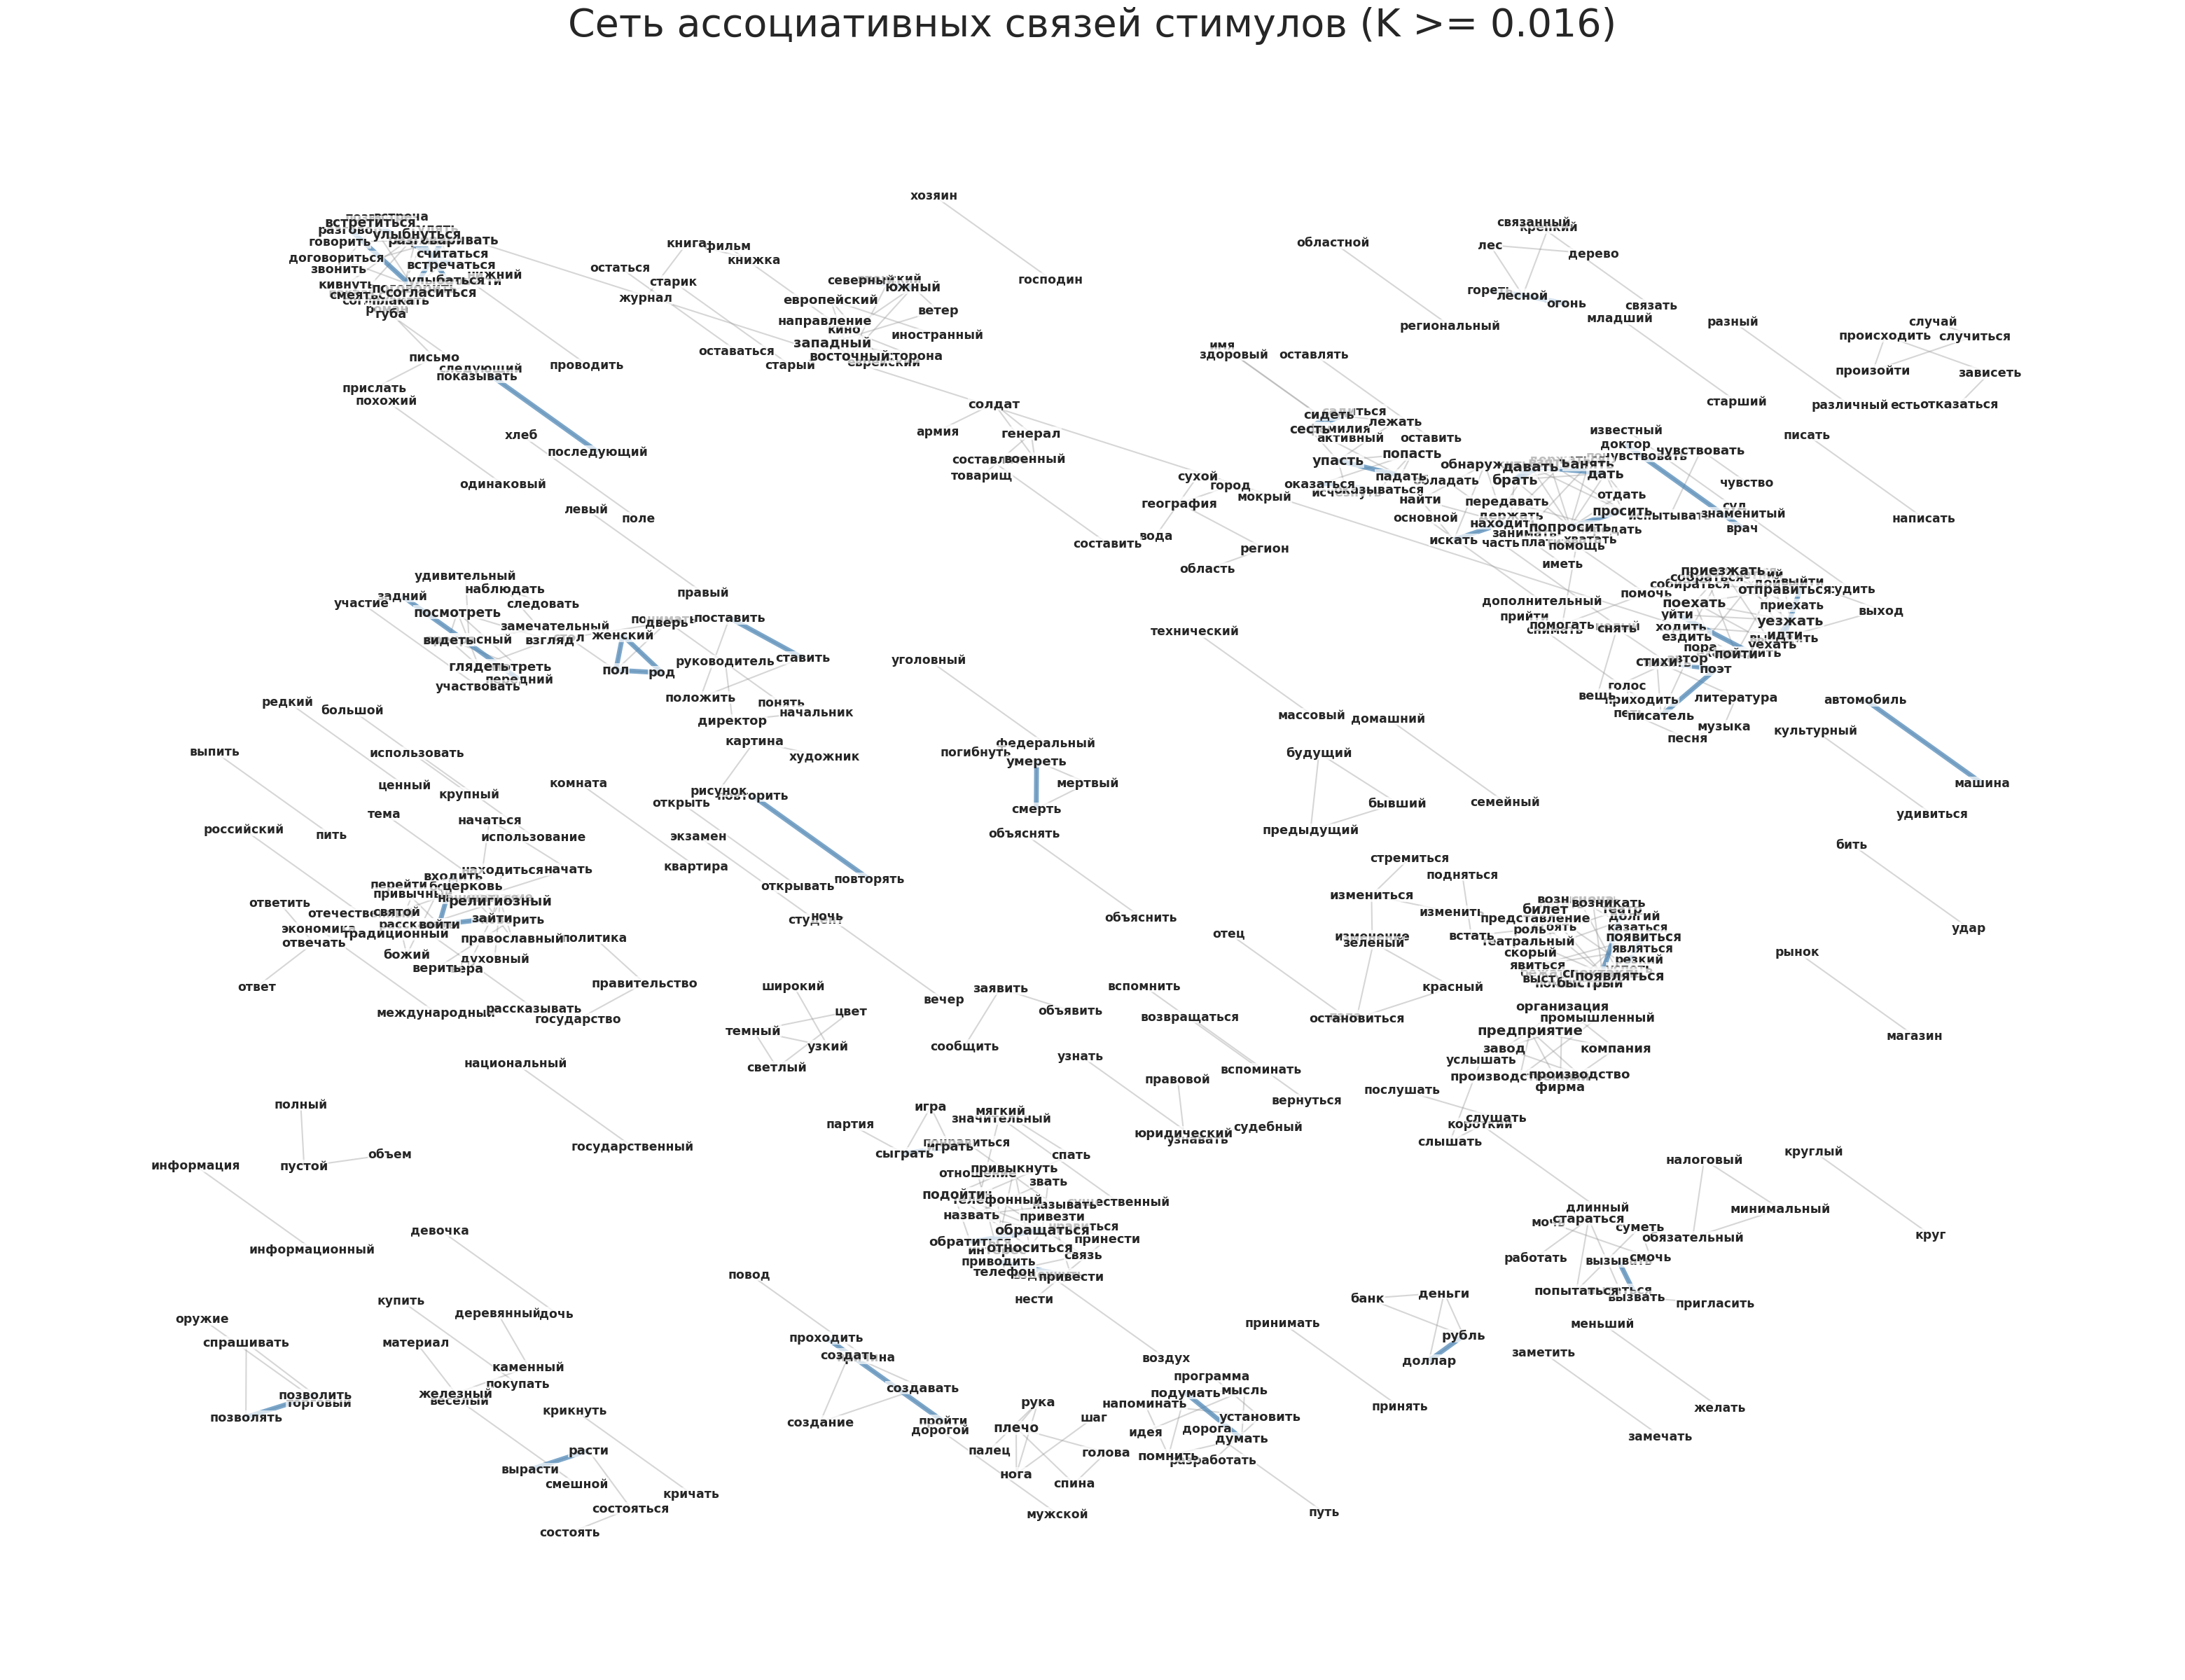

In [ ]:
communities = list(nx.community.greedy_modularity_communities(G_final))

fig = plt.figure(figsize=(40, 30))
pos = {}
rng = np.random.default_rng(seed=42)
group_centers = {i: rng.uniform(-15, 15, size=2) for i in range(len(communities))}

for i, comm in enumerate(communities):
    subgraph = G_final.subgraph(comm)
    local_pos = nx.spring_layout(subgraph, k=3.0, iterations=200, seed=42)
    for node in comm:
        pos[node] = local_pos[node] + group_centers[i]

# ребра (слабые и сильные)
nx.draw_networkx_edges(G_final, pos, width=1.5, alpha=0.4, edge_color='#999999')

strong_edges = [(u, v) for u, v, d in G_final.edges(data=True) if d['weight'] > 0.045]
nx.draw_networkx_edges(G_final, pos, edgelist=strong_edges, width=5.0, alpha=0.7, edge_color='steelblue')

# узлы
# важные узлы поверх остальных
sorted_nodes = sorted(G_final.nodes(), key=lambda n: centrality_degree[n])

for node in sorted_nodes:
    x, y = pos[node]
    # размер шрифта зависит от центральности
    font_sz = 12 + (centrality_degree[node] * 180)

    plt.text(x, y, s=node,
             fontsize=min(font_sz, 26),
             fontweight='bold',
             ha='center', va='center',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.3))

plt.axis('off')
plt.title(f"Сеть ассоциативных связей стимулов (K >= {threshold_k})", fontsize=40, pad=20)


fig.savefig('graph_final.png', dpi=300, bbox_inches='tight')
fig.savefig('graph_final.pdf', bbox_inches='tight')

plt.show()

In [ ]:
# Сохранение модели графа
nx.write_graphml(G_final, "associative_network.graphml")




In [ ]:
# функция для поиска по графу общих лемм-ассоциаций для двух стимулов
def general_lemmas(stim1, stim2, shared_df):

    # по shared_df ищем строки, где оба стимула указаны в списке
    mask = shared_df['список стимулов'].apply(lambda x: stim1 in x and stim2 in x)
    common_lemmas = shared_df[mask].copy()

    if common_lemmas.empty:
        print(f"Общих лемм между '{stim1}' and '{stim2}' в этой таблице не найдено.")
        return

    print(f"Семантический мост: между {stim1} и {stim2}")
    print(f"Всего общих лемм-ассоциаций: {len(common_lemmas)}")

    print("\nОбщие ассоциации:")
    print(", ".join(common_lemmas['лемма'].tolist()))


general_lemmas('папа', 'мама', shared_lemmas)

Семантический мост: между папа и мама
Всего общих лемм-ассоциаций: 34

Общие ассоциации:
человек, дом, хороший, мой, любовь, семья, радость, помощь, любимый, главный, добрый, мама, любить, родной, рядом, спокойствие, тепло, папа, родитель, добро, злой, защита, забота, доверие, поддержка, уважение, детство, веселие, сложность, опора, доброта, надежность, нежность, воспитание


In [ ]:
# топ-5 групп
for i, comm in enumerate(communities[:5], 1):
    print(f"Группа {i} ({len(comm)} слов):")
    print(", ".join(sorted(list(comm))))


Группа 1 (23 слов):
бежать, билет, быстрый, возникать, возникнуть, выступать, долгий, казаться, лететь, показаться, появиться, появляться, представление, резкий, роль, скорый, спектакль, сцена, театр, театральный, успеть, явиться, являться
Группа 2 (19 слов):
встретиться, встреча, встречаться, говорить, гулять, договориться, звонить, кивнуть, плакать, поговорить, позвонить, разговаривать, разговор, смеяться, согласиться, согласный, считаться, улыбаться, улыбнуться
Группа 3 (19 слов):
двигаться, дойти, ездить, ехать, идти, летний, отправиться, поехать, пойти, пора, приезжать, приехать, собираться, собраться, уезжать, уехать, уйти, уходить, ходить
Группа 4 (15 слов):
брать, взять, давать, дать, держать, держаться, занимать, занять, отдать, передавать, передать, платить, попросить, просить, хватать
Группа 5 (12 слов):
бог, божий, вера, верить, духовный, поверить, православный, привычный, религиозный, святой, традиционный, церковь


In [ ]:
df_graph_metrics.to_csv('7_graph_metrics.csv', index=False, encoding='utf-8-sig')